<a href="https://colab.research.google.com/github/amakello/Kujenga/blob/main/Akello_Odundo_Kenya_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RESEARCH QUESTION

**In Kenya, are Persons With Disabilities more likely to face unemployment than non-disabled persons?**

## Significance of the Question

 In Kenya, [Persons With Disabilities](https://new.kenyalaw.org/akn/ke/act/2025/4/eng@2025-05-13?#part_I__sec_2) are defined as anyone with a long-term impairment, which may hinder their participation in society on an equal basis with others. The long-term nature is what distinguishes disability from temporary conditions. Long-term is typically designated as lasting or likely to last at least 12 months.

 This researcher wishes to establish a research gap in order to strategize on inclusion measures. A preliminary Literature Review returned that Persons With Disability are more likely to face unemployment than non-disabled persons. By proving this using statistical methods, this researcher can numerically strengthen her research gap.

# BUILDING THE DATASET

To run a hypothesis test on whether Persons With Disabilities (PWDs) in Kenya are more likely to face unemployment than non-disabled persons, a dataset was needed. This dataset had to contain Employment Status (employed/unemployed) and Disability Status (disabled/non-disabled) of Kenyans.

A simulated dataset was built using statistical information available from the Kenya National Bureau of Statistics and National Council for Persons With Disabilities.

 I created a simple dataset with two variables:


*   *disability:* 1 if the person has a disability, 0 otherwise
*   *employment:* 1 if employed, 0 if unemployed


**Disability Status**

A population size (n) of 200 individuals was chosen.

According to the 2019 Kenya Population and Housing Census  [Disability Atlas](https://www.knbs.or.ke/wp-content/uploads/2019/01/2019-KPHC-Atlas-Disability.pdf), approximately 2.2% of Kenyans (about 0.9 million people) live with some form of disability. This rate was used to reflect the real-world situation.

A seed was also set to ensure the random number generation was reproducible every time the code was ran.

In [53]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of individuals
n = 200

# Simulate Kenya disability status (about 2.2% disabled)
disability = np.random.choice([0,1], size=n, p=[0.978 ,0.022])

**Employment Status**

The unemployment status was set for Persons With Disabilities as well as non-disabled persons using figures from the UNDP's [Disability Inclusion Status Report 2025](https://www.undp.org/kenya/publications/building-inclusive-kenya-disability-inclusion-status-report-2025) for Kenya.

The employment figures for the total Kenyan workforce were:

*   *Persons With Disabilities:* 10.45% Unemployed, 89.55% Employed
*   *Non-Disabled Persons:* 5.2% Unemployed, 94.8% Employed


In [54]:
# Simulate employment status

employed = []
for d in disability:
    if d == 1:  # disabled
        employed.append(np.random.choice([0,1], p=[0.1045, 0.8955]))
    else:       # non-disabled
        employed.append(np.random.choice([0,1], p=[0.052 ,0.948]))

The two lists were then combined into a pandas DataFrame.

This 200 row data set allowed me to test my hypothesis.

In [55]:
# Load in the simulated DataSet
Rev_disability_data = pd.DataFrame({
    'disability': disability,
    'employed': employed
})

# DATA ANALYSIS

**Define Hypothesis**


*   *Null hypothesis (H₀):* Persons With Disabilities in Kenya have the same unemployment rate as non-disabled persons.
*   *Alternative hypothesis (H₁):* Persons With Disabilities in Kenya have a higher unemployment rate than non-disabled persons.

In [56]:
import pandas as pd

# Load in the simulated DataSet
Disability_data = pd.DataFrame({
    'disability': disability,
    'employed': employed
})

df = Disability_data

## Unemployment Rate Calculation

In [57]:
# Separate the data into disabled and non-disabled groups
disabled_group = df[df['disability'] == 1]
non_disabled_group = df[df['disability'] == 0]

# Calculate unemployment for disabled group
unemployed_disabled = disabled_group[
    disabled_group['employed'] == 0
].shape[0]
total_disabled = disabled_group.shape[0]

# Calculate unemployment for non-disabled group
unemployed_non_disabled = non_disabled_group[
    non_disabled_group['employed'] == 0
].shape[0]
total_non_disabled = non_disabled_group.shape[0]

# Calculate unemployment rates
unemployment_rate_disabled = (
    (unemployed_disabled / total_disabled) * 100
    if total_disabled > 0 else 0
)
unemployment_rate_non_disabled = (
    (unemployed_non_disabled / total_non_disabled) * 100
    if total_non_disabled > 0 else 0
)

print(f"Unemployment rate for Persons With Disabilities: "
      f"{unemployment_rate_disabled:.2f}%")
print(f"Unemployment rate for Non-Disabled Persons: "
      f"{unemployment_rate_non_disabled:.2f}%")

Unemployment rate for Persons With Disabilities: 50.00%
Unemployment rate for Non-Disabled Persons: 8.08%


The results show that Persons With Disabilities have higher unemployment rates that non-disabled persons. But maybe that difference happened by chance. To reason rigorously, hypothesis testing will be used. It will evaluate whether the observed difference is likely real or just random variation.

## Chi-Squared Hypothesis Test

Unlike the t-statistic hypothesis test which involves one variable, the chi-squared hypothesis test is a more appropriate method for determining the association between two categorical variables. In this case, disability status and employment status.

In [58]:
from scipy.stats import chi2_contingency

# Create a contingency table
# Rows: Disability (1=disabled, 0=non-disabled)
# Columns: Employment (0=unemployed, 1=employed)

# Get counts for each group

employed_disabled = total_disabled - unemployed_disabled
employed_non_disabled = total_non_disabled - unemployed_non_disabled

contingency_table = [
    [employed_disabled, unemployed_disabled], # Disabled group (employed, unemployed)
    [employed_non_disabled, unemployed_non_disabled]
    # Non-disabled group (employed, unemployed)
]

print("Contingency Table (Rows: Disabled, Non-Disabled; "
      "Columns: Employed, Unemployed):")
print(contingency_table)

# Perform the Chi-squared test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"\nChi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the "
          f"significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant association "
          "between disability status and unemployment. Persons With "
          "Disabilities have a higher unemployment rate than "
          "non-disabled persons.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the "
          f"significance level ({alpha}), we fail to reject the null "
          "hypothesis.")
    print("Conclusion: There is no statistically significant association "
          "between disability status and unemployment.")

Contingency Table (Rows: Disabled, Non-Disabled; Columns: Employed, Unemployed):
[[1, 1], [182, 16]]

Chi-squared statistic: 0.71
P-value: 0.400

Since the p-value (0.400) is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: There is no statistically significant association between disability status and unemployment.


## Two-Sample Z-Statistic Hypothesis Testing

Alternatively, a two-sample z-test can be performed for proportions to directly compare the unemployment rates between the disabled and non-disabled groups.

In [59]:
from statsmodels.stats.proportion import proportions_ztest

# Number of unemployed individuals in each group
count = np.array([unemployed_disabled, unemployed_non_disabled])

# Total number of individuals in each group
nobs = np.array([total_disabled, total_non_disabled])

# Perform the two-sample z-test for proportions
# The alternative='larger' indicates that we are testing if the proportion
# of the first group (disabled) is larger than the second group (non-disabled).
z_statistic, p_value_ztest = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-statistic: {z_statistic:.2f}")
print(f"P-value (Z-test): {p_value_ztest:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_ztest < alpha:
    print(f"\nSince the p-value ({p_value_ztest:.3f}) is less than the "
          f"significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant higher "
          "unemployment rate for Persons With Disabilities compared to "
          "non-disabled persons.")
else:
    print(f"\nSince the p-value ({p_value_ztest:.3f}) is greater than the "
          f"significance level ({alpha}), we fail to reject the null "
          "hypothesis.")
    print("Conclusion: There is no statistically significant higher "
          "unemployment rate for Persons With Disabilities compared to "
          "non-disabled persons.")

Z-statistic: 2.12
P-value (Z-test): 0.017

Since the p-value (0.017) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant higher unemployment rate for Persons With Disabilities compared to non-disabled persons.


## Visualizing Unemployment Rates

Analyzing the two hypothesis tests:

Chi-squared statistic: 0.71 &  P-value: 0.400

Since the p-value (0.400) is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: There is no statistically significant association between disability status and unemployment.

Z-statistic: 2.12 & P-value (Z-test): 0.017

Since the p-value (0.017) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant higher unemployment rate for Persons With Disabilities compared to non-disabled persons.

The Chi-Squared hypothesis test draws the conclusion that there is no significant relationship between disability and unemployment in Kenya.

Meanwhile, the hypothesis test draws the conclusion that Persons With Disabilities are more likely to face unemployment than non-disabled persons. This conclusion can be made clearer using a visualization.

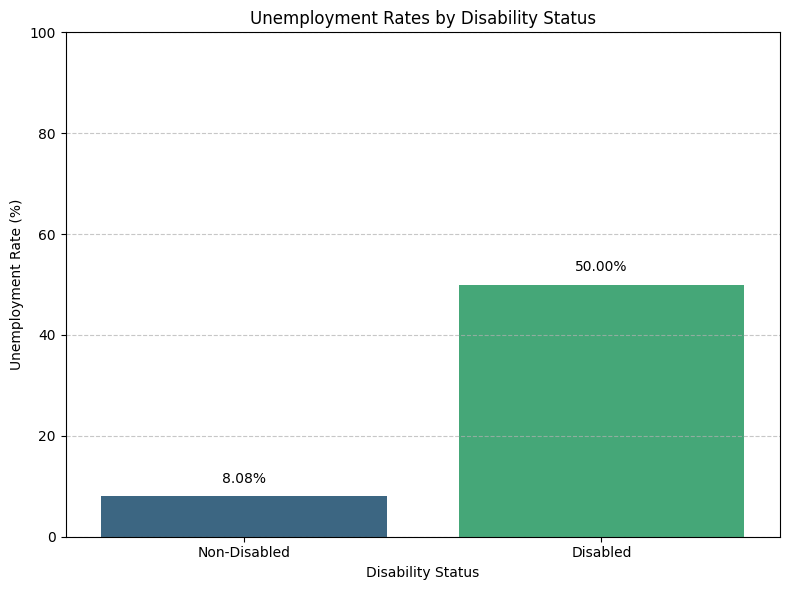

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the unemployment rates to numeric for plotting
unemployment_rates_for_plot = unemployment_rates_display['Unemployment Rate'].str.replace('%', '').astype(float)

plt.figure(figsize=(8, 6))
sns.barplot(
    x=unemployment_rates_for_plot.index,
    y=unemployment_rates_for_plot.values,
    hue=unemployment_rates_for_plot.index,
    palette='viridis',
    legend=False
)
plt.title('Unemployment Rates by Disability Status')
plt.xlabel('Disability Status')
plt.ylabel('Unemployment Rate (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100%

# Add percentage labels on top of the bars
for index, value in enumerate(unemployment_rates_for_plot.values):
    plt.text(
        index, value + 2, f'{value:.2f}%',
        ha='center', va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

Although the chi-squared hypothesis test reveals no significant relationship between disability status and unemployment status in Kenya, three other sources overwhelmingly contradict this finding.

They are:

1.   The Literature Review
2.   The Z-Statistic Hypothesis Test
3.   The Histogram (Visualization)

With a 3:1 results ratio, it is concluded that in Kenya, Persons With Disabilities are more likely to face unemployment than non-disabled persons.





# BUILDING THE REVISED DATASET

There are disparities between local and international figures on disability prevalence in Kenya. The difference comes from how disability is defined, measured, and reported.

Similarly, there are differences in reported unemployment rates from the Kenyan government and independent sources.

A revised DataSet was simulated to account for these differences.

**Disability Status**

[World Health Organization](https://www.who.int/teams/noncommunicable-diseases/sensory-functions-disability-and-rehabilitation/world-report-on-disability?) argues that the Kenya National Bureau of Statistics figures of 2.2% Kenyan disability rates are grossly under reported, putting actual disability numbers at approximately 15% of Kenya's population.

In [61]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of individuals
n = 200

# Simulate revised Kenya disability status (about 15% disabled)
rev_disability = np.random.choice([0,1], size=n, p=[0.85 ,0.15])

**Employment Status**

The UNDP's Disability Inclusion Status Report 2025 for Kenya puts unemployment figures at 10.45% for Persons With Disabilities and 5.2% for non-diabled persons. Independent reports estimate that Kenya experiences as high as 45% unemployment rates for Persons With Disabilities and 12% for non-disabled persons.

In [62]:
# Simulate revised Kenya employment status

rev_employed = []
for d in rev_disability:
    if d == 1:  # disabled
        rev_employed.append(np.random.choice([0,1], p=[0.45 , 0.55]))
    else:       # non-disabled
        rev_employed.append(np.random.choice([0,1], p=[0.12 ,0.88]))

The two lists were then combined into a pandas DataFrame.

This 200 row data set allowed hypothesis testing.

In [66]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of individuals
n = 200

# Simulate Kenya revised disability status (about 15% disabled)
rev_disability = np.random.choice([0, 1], size=n, p=[0.85, 0.15])

# Simulate employment status
rev_employed = []
for d in rev_disability:
    if d == 1:  # disabled
        rev_employed.append(np.random.choice([0, 1], p=[0.45, 0.55]))
    else:       # non-disabled
        rev_employed.append(np.random.choice([0, 1], p=[0.12, 0.88]))

# Load in the simulated DataSet
Rev_disability_data = pd.DataFrame({
    'revised_disability': rev_disability,
    'revised_employed': rev_employed
})

# REVISED DATA ANALYSIS

**Define Hypothesis**


*   *Null hypothesis (H₀):* Persons With Disabilities in Kenya have the same unemployment rate as non-disabled persons.
*   *Alternative hypothesis (H₁):* Persons With Disabilities in Kenya have a higher unemployment rate than non-disabled persons.

## Revised Unemployment Rate Calculation

In [70]:
# Separate the data into disabled and non-disabled groups
rev_disabled_group = Rev_disability_data[Rev_disability_data['revised_disability'] == 1]
rev_non_disabled_group = Rev_disability_data[Rev_disability_data['revised_disability'] == 0]

# Calculate unemployment for disabled group
rev_unemployed_disabled = rev_disabled_group[
    rev_disabled_group['revised_employed'] == 0
].shape[0]
total_rev_disabled = rev_disabled_group.shape[0]

# Calculate unemployment for non-disabled group
rev_unemployed_non_disabled = rev_non_disabled_group[
    rev_non_disabled_group['revised_employed'] == 0
].shape[0]
total_rev_non_disabled = rev_non_disabled_group.shape[0]

# Calculate unemployment rates
rev_unemployment_rate_disabled = (
    (rev_unemployed_disabled / total_rev_disabled) * 100
    if total_rev_disabled > 0 else 0
)
rev_unemployment_rate_non_disabled = (
    (rev_unemployed_non_disabled / total_rev_non_disabled) * 100
    if total_rev_non_disabled > 0 else 0
)

print(f"Revised unemployment rate for Persons With Disabilities: "
      f"{rev_unemployment_rate_disabled:.2f}%")
print(f"Revised unemployment rate for Non-Disabled Persons: "
      f"{rev_unemployment_rate_non_disabled:.2f}%")

Revised unemployment rate for Persons With Disabilities: 48.39%
Revised unemployment rate for Non-Disabled Persons: 15.38%


The revised results show that Persons With Disabilities have higher unemployment rates that non-disabled persons. But maybe that difference happened by chance. To reason rigorously, hypothesis testing will be used. It will evaluate whether the observed difference is likely real or just random variation.

## Hypothesis Testing: Chi-Squared Test

Unlike the t-statistic hypothesis test which involves one variable, the chi-squared hypothesis test is a more appropriate method for determining the association between two categorical variables. In this case, disability status and employment status.

In [74]:
from scipy.stats import chi2_contingency

# Create a contingency table
# Rows: Revised Disability (1=disabled, 0=non-disabled)
# Columns: Revised Employment (0=unemployed, 1=employed)

# Get counts for each group for the REVISED DATASET

rev_employed_disabled = total_rev_disabled - rev_unemployed_disabled
rev_employed_non_disabled = total_rev_non_disabled - rev_unemployed_non_disabled

contingency_table = [
    [rev_employed_disabled, rev_unemployed_disabled], # Disabled group (employed, unemployed)
    [rev_employed_non_disabled, rev_unemployed_non_disabled] # Non-disabled group (employed, unemployed)
]

print("Contingency Table (Rows: Revised Disabled, Revised Non-Disabled; Columns: "
      "Revised Employed, Revised Unemployed):")
print(contingency_table)

# Perform the Chi-squared test
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"\nChi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the "
          f"significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant association "
          "between disability status and unemployment. Persons With "
          "Disabilities have a higher unemployment rate than non-disabled "
          "persons.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the "
          f"significance level ({alpha}), we fail to reject the null "
          "hypothesis.")
    print("Conclusion: There is no statistically significant association "
          "between disability status and unemployment.")

Contingency Table (Rows: Revised Disabled, Revised Non-Disabled; Columns: Revised Employed, Revised Unemployed):
[[16, 15], [143, 26]]

Chi-squared statistic: 15.54
P-value: 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant association between disability status and unemployment. Persons With Disabilities have a higher unemployment rate than non-disabled persons.


## Hypothesis Testing: Two-Sample Z-Test for Proportions

Alternatively, a two-sample z-test can be performed for proportions to directly compare the unemployment rates between the disabled and non-disabled groups.

In [75]:
from statsmodels.stats.proportion import proportions_ztest

# Number of unemployed individuals in each group
count = np.array([rev_unemployed_disabled, rev_unemployed_non_disabled])

# Total number of individuals in each group
nobs = np.array([total_rev_disabled, total_rev_non_disabled])

# Perform the two-sample z-test for proportions
# The alternative='larger' indicates that we are testing if the proportion
# of the first group (disabled) is larger than the second group (non-disabled).
z_statistic, p_value_ztest = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-statistic: {z_statistic:.2f}")
print(f"P-value (Z-test): {p_value_ztest:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_ztest < alpha:
    print(f"\nSince the p-value ({p_value_ztest:.3f}) is less than the "
          f"significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant higher "
          "unemployment rate for Persons With Disabilities compared to "
          "non-disabled persons.")
else:
    print(f"\nSince the p-value ({p_value_ztest:.3f}) is greater than the "
          f"significance level ({alpha}), we fail to reject the null "
          "hypothesis.")
    print("Conclusion: There is no statistically significant higher "
          "unemployment rate for Persons With Disabilities compared to "
          "non-disabled persons.")

Z-statistic: 4.18
P-value (Z-test): 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant higher unemployment rate for Persons With Disabilities compared to non-disabled persons.


## Visualization: Unemployment Rate Comparison

Analyzing the two hypothesis tests:

Chi-squared statistic: 15.54 & P-value: 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant association between disability status and unemployment. Persons With Disabilities have a higher unemployment rate than non-disabled persons.

Z-statistic: 4.18 & P-value: 0.000

Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is a statistically significant higher unemployment rate for Persons With Disabilities compared to non-disabled persons.

Both tests draw the conclusion that Persons With Disabilities are more likely to face unemployment than non-disabled persons. This conclusion can be made clearer using a visualization.

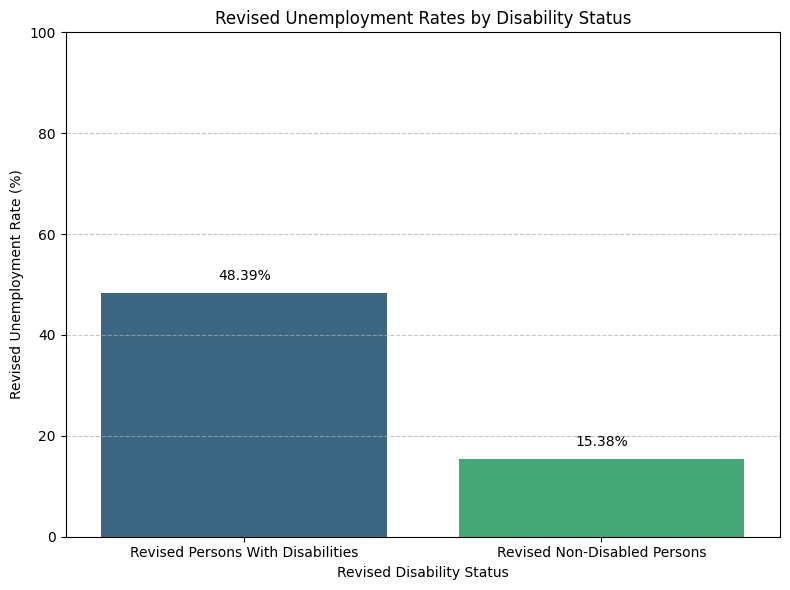

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the revised unemployment rates for plotting from df_rev_unemployment
# Set 'Group' as index and select the unemployment rate column
rev_unemployment_rates_for_plot = df_rev_unemployment.set_index('Group')['Revised Unemployment Rate (%)']

plt.figure(figsize=(8, 6))
sns.barplot(
    x=rev_unemployment_rates_for_plot.index,
    y=rev_unemployment_rates_for_plot.values,
    hue=rev_unemployment_rates_for_plot.index,
    palette='viridis',
    legend=False
)
plt.title('Revised Unemployment Rates by Disability Status')
plt.xlabel('Revised Disability Status')
plt.ylabel('Revised Unemployment Rate (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100%

# Add percentage labels on top of the bars
for index, value in enumerate(rev_unemployment_rates_for_plot.values):
    plt.text(
        index, value + 2, f'{value:.2f}%',
        ha='center', va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

For the revised DataSet, both the chi-squared hypothesis test and the z-statistic hypothesis test reveal a significant relationship between disability status and unemployment status in Kenya.

With the revised DataSet, it can be concluded that in Kenya, Persons With Disabilities are more likely to face unemployment than non-disabled persons.





# OVERALL CONCLUSION

**In Kenya, are Persons With Disabilities more likely to face unemployment than non-disabled persons?**

The analysis of the original simulated DataSet based on locally reported disability and employment figures for Kenya, suggests Persons With Disabilities are more likely to face unemployment than non-disabled persons.

The analysis of the revised simulated DataSet based on internationally reported disability and employment figures for Kenya, suggests Persons With Disabilities are more likely to face unemployment than non-disabled persons.


**Fun Fact**

The visualizations for both the original DataSet and the Revised DataSet show disability unemployment figures of 50% and 48% respectively, in line with global estimates for Kenya. Interestingly, these figures are so similar despite the allegedly under reported numbers in local sources (10.45%). It's proof that data analysis reveals actual patterns despite attempts at under-reporting. Numbers don't lie.